In [16]:
import time
import torch
from matplotlib import pyplot as plt
import utils
import random
import numpy as np
import data_bonelesions as kahler
from torch.utils.data import DataLoader
import models


test_img_dir = "/wecare/home/daniel/Thesis/Dataset/224_patches/images/test/"
test_mask_dir = "/wecare/home/daniel/Thesis/Dataset/224_patches/labels/test/"
test_set = kahler.KahlerDataset(test_img_dir, test_mask_dir)

#data loaders
batch_size = 1

test_loader = DataLoader(test_set, batch_size=batch_size, shuffle=False)

device = torch.device("cuda")
model = models.SwinUnetFinetune()
model.to(device)
model.load_state_dict(torch.load("/wecare/home/daniel/Thesis/models/finetune_lesions_simmim_best.pth", weights_only=True), strict=False)
segment_output_save_path = "/wecare/home/daniel/Thesis/images/segmentations_lesions_simmim_imagenet_cbar.png"
plot_title = "SimMIM pretraining bone lesion segmentation"


SwinTransformerSys expand initial----depths:[2, 2, 2, 2];depths_decoder:[1, 2, 2, 2];drop_path_rate:0.1;num_classes:1
---final upsample expand_first---


/wecare/home/daniel/Thesis/images/segmentations_lesions_simmim_imagenet_cbar.png
Metrics runtime 14.180479288101196
Mean dice coefficient on test set: 0.3102
Standard deviation of dice coefficient on test set: 0.3141

Mean jaccard coefficient on test set: 0.2317
Mean precision on test set: 0.4358
Mean recall on test set: 0.3380

Number of undetected lesions on test set: 151
Mean dice coefficient for detected lesions: 0.4922
Standard deviation of dice coefficient for detected lesions: 0.2615


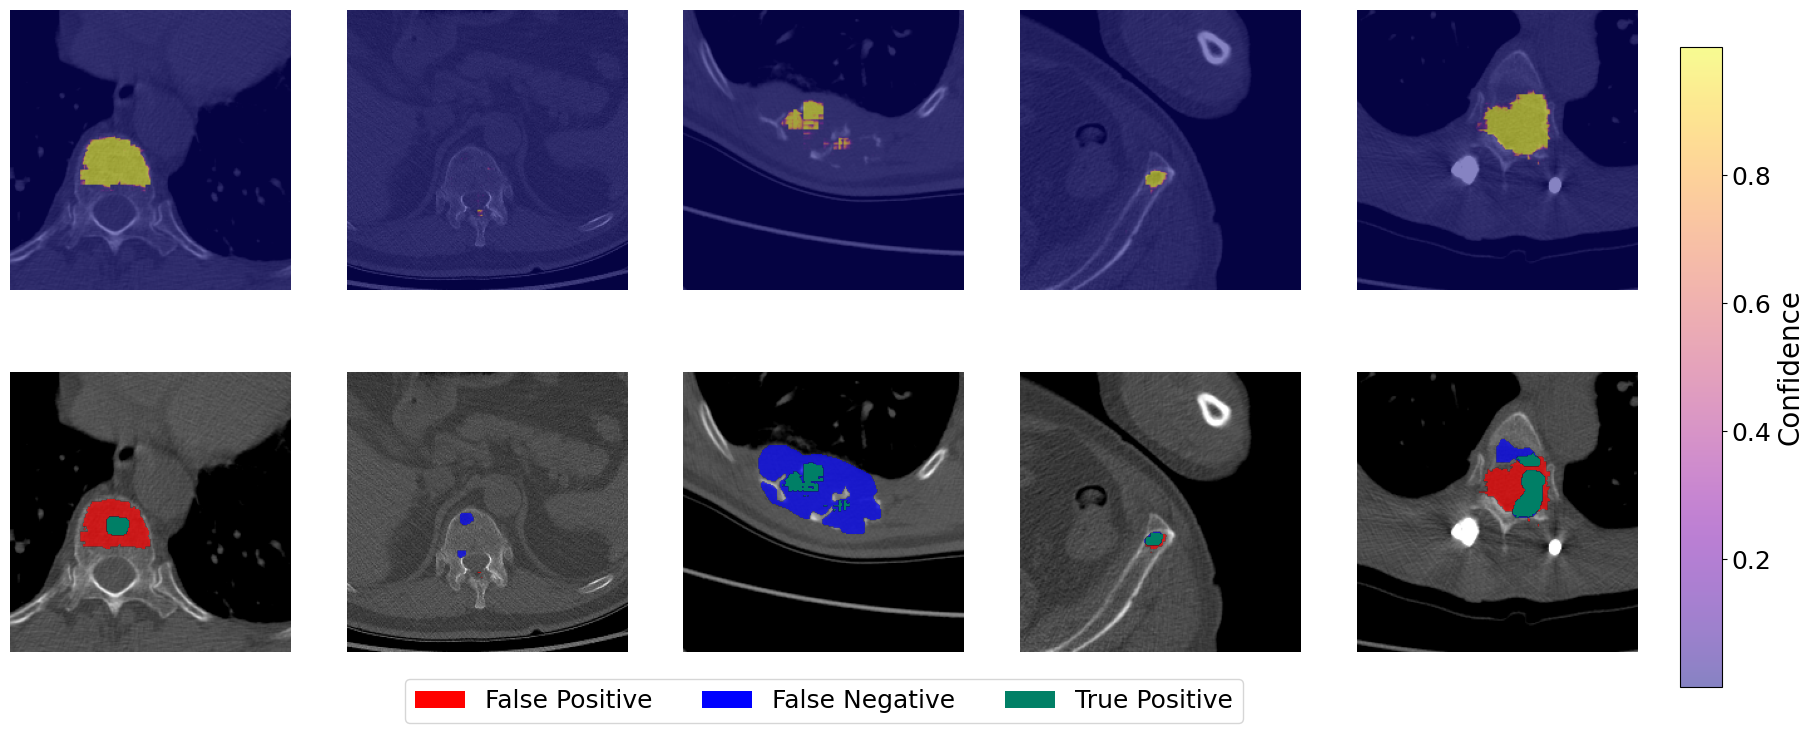

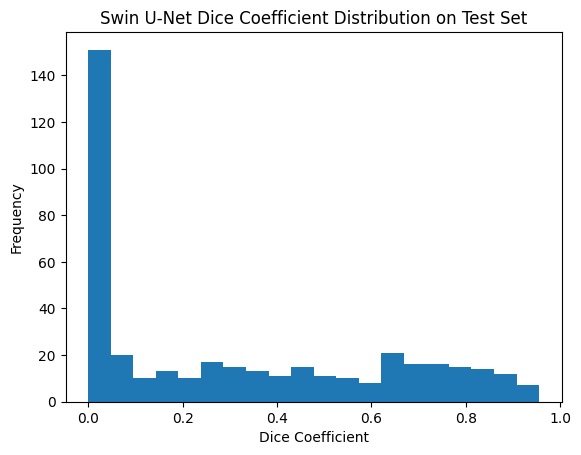

In [18]:

start = time.time()

#dice standard deviation
dice_list = []
iou_list = []
detected_dice_list = []
precision_list = []
recall_list = []
dice_m = 0.0
dice_sd = 0.0
detected_dice_m = 0.0
detected_dice_sd = 0.0
undetected_count = 0

idx_undetected = []
idx_detected = []
idx_random_list = []

model.eval()

with torch.no_grad():
    #unbatching all the test images and masks to calculate metrics individually
    for idx_batch, (images, masks) in enumerate(test_loader):

        images, masks = images.to(device), masks.to(device)

        images_list = torch.unbind(images, dim=0)
        masks_list = torch.unbind(masks, dim=0)

        for idx_inside, (unbatched_image, unbatched_masks) in enumerate(zip(images, masks)):

            #calculating dice scores
            #print(unbatched_image.shape, unbatched_masks.shape, idx_batch)
            unbatched_output = model(unbatched_image.unsqueeze(0))
            unbatched_dice, _ = utils.dice_coeff(unbatched_output, unbatched_masks.unsqueeze(0))
            dice_list.append(unbatched_dice)

            #calculating iou scores
            unbatched_iou, _ = utils.jaccard_coeff(unbatched_output, unbatched_masks.unsqueeze(0))
            iou_list.append(unbatched_iou)

            #calculating detected lesion dice scores
            if unbatched_dice < 0.05:
                undetected_count += 1
                idx_undetected.append([idx_batch, idx_inside])
            if unbatched_dice >= 0.05:
                detected_dice_list.append(unbatched_dice)
                idx_detected.append([idx_batch, idx_inside])
            idx_random_list.append([idx_batch, idx_inside])

            #calculating precision and recall
            unbatched_precision = utils.precision(unbatched_output, unbatched_masks.unsqueeze(0))
            unbatched_recall = utils.recall(unbatched_output, unbatched_masks.unsqueeze(0))
            precision_list.append(unbatched_precision)
            recall_list.append(unbatched_recall)


    #plotting the images and their segmentations

    from matplotlib.patches import Patch
    import matplotlib.cm as cm
    import matplotlib.cm as cm

    random.seed(1)
    #idx_detected_sampled = random.sample(idx_detected, 5)

    idx_random = random.sample(idx_random_list, 5)

    fig, axes = plt.subplots(2, 5, figsize=(21, 8))
    #fig.suptitle(plot_title, fontsize=28)
    plt.subplots_adjust(top=0.94)

    

    legend_elements = [
        Patch(facecolor=cm.autumn(1), label='False Positive'),
        Patch(facecolor=cm.winter(1), label='False Negative'),
        Patch(facecolor=cm.summer(1), label='True Positive')
    ]

    axes[1, 2].legend(
        handles=legend_elements,
        loc='upper center',
        bbox_to_anchor=(0.5, -0.05),
        ncol=5,
        frameon=True,
        prop={'size': 18},
    )

    for index, (sample) in enumerate(idx_random):
        
        idx_search = idx_random[index]

        #getting the images from the loader and plotting them
        for idx_batch, (images, masks) in enumerate(test_loader):

            images, masks = images.to(device), masks.to(device)

            for idx_inside, (unbatched_image, unbatched_masks) in enumerate(zip(images, masks)):

                if idx_search == [idx_batch, idx_inside]:

                    #print(unbatched_image.shape)
                    axes[0, index].axis('off')
                    axes[1, index].axis('off')

                    axes[0, index].imshow((unbatched_image.squeeze(0).cpu()), cmap='gray')
                    axes[1, index].imshow((unbatched_image.squeeze(0).cpu()), cmap='gray')
                    unbatched_output = model(unbatched_image.unsqueeze(0))
                    im = axes[0, index].imshow((unbatched_output.squeeze([0,1]).cpu()), alpha=0.5, cmap='plasma')

                    if index == 4:
                        cax = fig.add_axes([0.92, 0.08, 0.02, 0.8])
                        cbar = fig.colorbar(im, cax=cax, orientation='vertical')
                        cbar.ax.tick_params(labelsize=18)
                        cbar.set_label('Confidence', fontsize = 20)

                    thresh_output = (unbatched_output > 0.5).squeeze([0,1]).cpu()
                    union =  (thresh_output * unbatched_masks.squeeze(0).cpu())
                    unbatched_masks = unbatched_masks.cpu()

                    segment_output = np.ma.masked_where(thresh_output == 0, thresh_output)
                    ground_truth = np.ma.masked_where(unbatched_masks.squeeze(0) == 0, unbatched_masks.squeeze(0))
                    union_output = np.ma.masked_where(union == 0, union)

                    axes[1, index].imshow(segment_output, alpha=0.7, cmap='autumn')
                    axes[1, index].imshow(ground_truth, alpha=0.7, cmap='winter')
                    axes[1, index].imshow(union_output, alpha=1, cmap='summer')
    plt.savefig(segment_output_save_path)
    print(segment_output_save_path)            



#mean dice
dice_m = sum(dice_list) / len(dice_list)
for dice_val in dice_list:
    dice_sd += (dice_val - dice_m) ** 2
dice_sd = (dice_sd / len(dice_list)) ** 0.5

#mean iou
iou_m = sum(iou_list) / len(iou_list)

#mean dice for detected lesions
detected_dice_m = sum(detected_dice_list) / len(detected_dice_list)
for detected_dice_val in detected_dice_list:
    detected_dice_sd += (detected_dice_val - detected_dice_m) ** 2
detected_dice_sd = (detected_dice_sd / len(detected_dice_list)) ** 0.5

#mean precision and recall
precision_m = sum(precision_list) / len(precision_list)
recall_m = sum(recall_list) / len(recall_list)

plt.figure()
plt.hist(dice_list, bins=20)
plt.title('Swin U-Net Dice Coefficient Distribution on Test Set')
plt.xlabel('Dice Coefficient')
plt.ylabel('Frequency')
#plt.show()


end = time.time()

#print(idx_undetected, idx_detected)

print(f"Metrics runtime {end - start}")
print(f"Mean dice coefficient on test set: {dice_m:.4f}")
print(f"Standard deviation of dice coefficient on test set: {dice_sd:.4f}")
print()
print(f"Mean jaccard coefficient on test set: {iou_m:.4f}")
print(f"Mean precision on test set: {precision_m:.4f}")
print(f"Mean recall on test set: {recall_m:.4f}")
print()
print(f"Number of undetected lesions on test set: {undetected_count}")
print(f"Mean dice coefficient for detected lesions: {detected_dice_m:.4f}")
print(f"Standard deviation of dice coefficient for detected lesions: {detected_dice_sd:.4f}")